In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# 1. Gỡ numpy cũ và cài đúng phiên bản tương thích
!pip uninstall -y numpy
!pip install numpy==1.25.0

In [2]:
# 2 Cài các thư viện phụ thuộc cho torch_geometric
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv \
  -f https://data.pyg.org/whl/torch-2.1.0+cu118.html

# Cài torch_geometric
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 53.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.8/891.8 kB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.5 MB/s eta 0:00:00


In [8]:
!pip install networkx

# Tiền xử lý dữ liệu

In [3]:
import pandas as pd
import numpy as np

In [36]:
# Đọc file .txt với separator tab (\t)
file_path = '/content/drive/MyDrive/Colab Notebooks/BIOGRID-CORONAVIRUS.csv'

# Đọc file .txt vào DataFrame
df = pd.read_csv(file_path)

In [37]:
df.head()

,#BioGRID Interaction ID,Entrez Gene Interactor A,Entrez Gene Interactor B,BioGRID ID Interactor A,BioGRID ID Interactor B,Systematic Name Interactor A,Systematic Name Interactor B,Official Symbol Interactor A,Official Symbol Interactor B,Synonyms Interactor A,...,TREMBL Accessions Interactor B,REFSEQ Accessions Interactor B,Ontology Term IDs,Ontology Term Names,Ontology Term Categories,Ontology Term Qualifier IDs,Ontology Term Qualifier Names,Ontology Term Types,Organism Name Interactor A,Organism Name Interactor B
0,141211,850980,852501,31542,32899,YLR274W,YBR202W,MCM5,MCM7,BOB1|CDC46|MCM DNA helicase complex subunit MC...,...,-,NP_009761,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
1,141212,852501,850980,32899,31542,YBR202W,YLR274W,MCM7,MCM5,CDC47|MCM DNA helicase complex subunit MCM7|L0...,...,-,NP_013376,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
2,141213,850980,856680,31542,36697,YLR274W,YEL032W,MCM5,MCM3,BOB1|CDC46|MCM DNA helicase complex subunit MC...,...,-,NP_010882,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
3,141214,856680,850980,36697,31542,YEL032W,YLR274W,MCM3,MCM5,MCM DNA helicase complex subunit MCM3|L000001039,...,-,NP_013376,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)
4,141215,852501,850793,32899,31376,YBR202W,YLR103C,MCM7,CDC45,CDC47|MCM DNA helicase complex subunit MCM7|L0...,...,-,NP_013204,-,-,-,-,-,-,Saccharomyces cerevisiae (S288c),Saccharomyces cerevisiae (S288c)


In [38]:
print(df.dtypes)

#BioGRID Interaction ID                int64
Entrez Gene Interactor A              object
Entrez Gene Interactor B              object
BioGRID ID Interactor A                int64
BioGRID ID Interactor B                int64
Systematic Name Interactor A          object
Systematic Name Interactor B          object
Official Symbol Interactor A          object
Official Symbol Interactor B          object
Synonyms Interactor A                 object
Synonyms Interactor B                 object
Experimental System                   object
Experimental System Type              object
Author                                object
Publication Source                    object
Organism ID Interactor A               int64
Organism ID Interactor B               int64
Throughput                            object
Score                                 object
Modification                          object
Qualifications                        object
Tags                                  object
Source Dat

In [39]:
print(df.isnull().sum())

#BioGRID Interaction ID                0
Entrez Gene Interactor A               0
Entrez Gene Interactor B               0
BioGRID ID Interactor A                0
BioGRID ID Interactor B                0
Systematic Name Interactor A           0
Systematic Name Interactor B           0
Official Symbol Interactor A           0
Official Symbol Interactor B           0
Synonyms Interactor A                  0
Synonyms Interactor B                  0
Experimental System                    0
Experimental System Type               0
Author                                 0
Publication Source                     0
Organism ID Interactor A               0
Organism ID Interactor B               0
Throughput                             0
Score                                  0
Modification                           0
Qualifications                         0
Tags                                   0
Source Database                        0
SWISS-PROT Accessions Interactor A     0
TREMBL Accession

In [40]:
# Lọc các cột cần dùng
df = df[[
    'Official Symbol Interactor A',
    'Official Symbol Interactor B',
    'BioGRID ID Interactor A',
    'BioGRID ID Interactor B',
    'Experimental System',
    'Score'  # Có thể giữ lại để làm trọng số
]]

In [41]:
df['Score'].isnull().sum()

0

In [42]:
print(df['Score'].unique())

['-' '0.963550095' '0.97848835' ... '0.04' '0.05' '0.02']


In [43]:
df.isnull().sum()

,0
Official Symbol Interactor A,0
Official Symbol Interactor B,0
BioGRID ID Interactor A,0
BioGRID ID Interactor B,0
Experimental System,0
Score,0


In [44]:
print(df.head())

  Official Symbol Interactor A Official Symbol Interactor B  \
0                         MCM5                         MCM7   
1                         MCM7                         MCM5   
2                         MCM5                         MCM3   
3                         MCM3                         MCM5   
4                         MCM7                        CDC45   

   BioGRID ID Interactor A  BioGRID ID Interactor B Experimental System Score  
0                    31542                    32899          Two-hybrid     -  
1                    32899                    31542          Two-hybrid     -  
2                    31542                    36697          Two-hybrid     -  
3                    36697                    31542          Two-hybrid     -  
4                    32899                    31376          Two-hybrid     -  


#Xây dựng đồ thị


In [20]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data

/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN3c1017Registe

#Mạng lưới tương tác của 20 protein quan trọng nhất

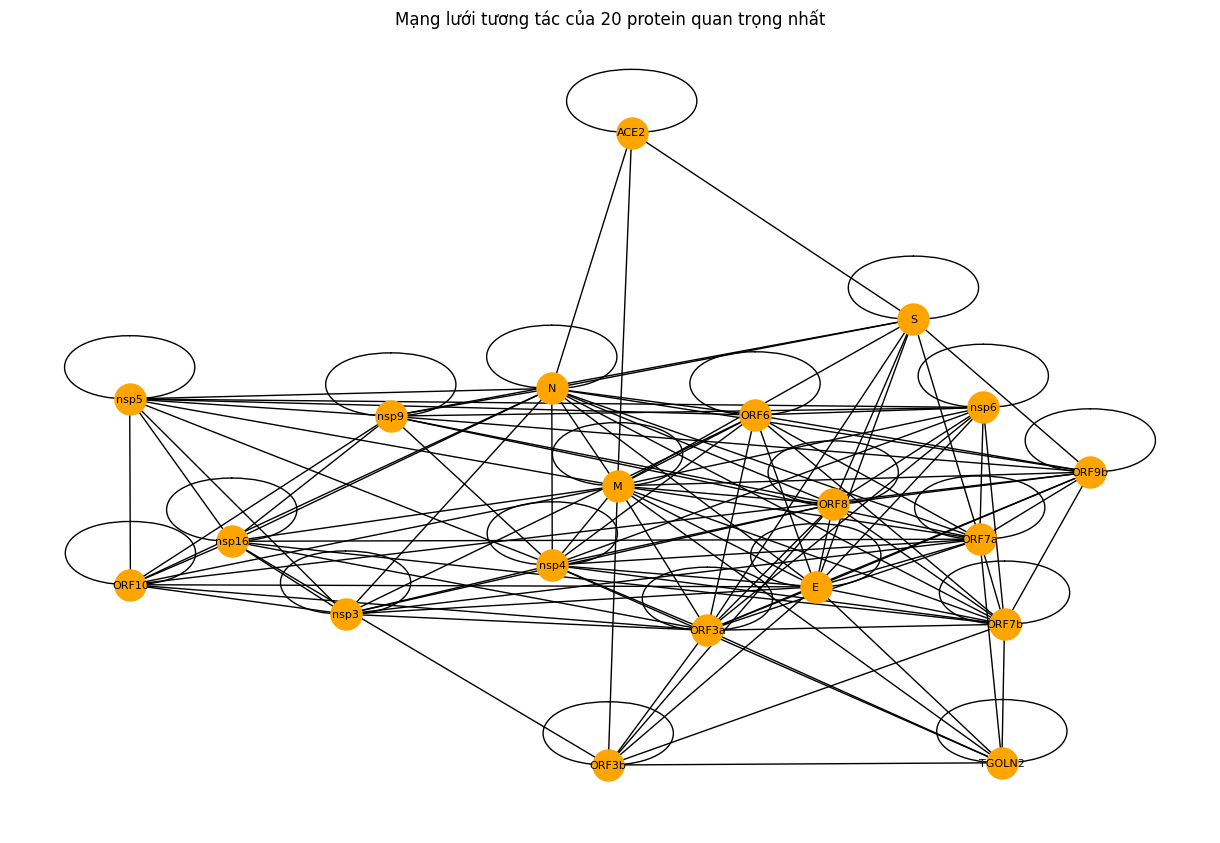

In [22]:
# Tạo đồ thị
G = nx.Graph()
# Tính độ trung tâm của các nút
#Độ trung tâm (Degree Centrality) là một chỉ số đo tầm quan trọng của một nút (protein) trong mạng bằng cách đếm số lượng kết nối (edges) của nó với các nút khác.
degree_centrality = nx.degree_centrality(G)

# Chọn top 20 protein quan trọng nhất---degree_centrality.get giúp sắp xếp dictionary theo giá trị thay vì key.
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:20]

# Tạo đồ thị con chứa 50 protein này
G_sub = G.subgraph(top_nodes)

# Vẽ đồ thị
plt.figure(figsize=(12, 8))
nx.draw(G_sub, with_labels=True, node_size=500, node_color="orange", edge_color="black", font_size=8)
plt.title("Mạng lưới tương tác của 20 protein quan trọng nhất")
plt.show()

#Phân phối bậc của nút (Degree Distribution)

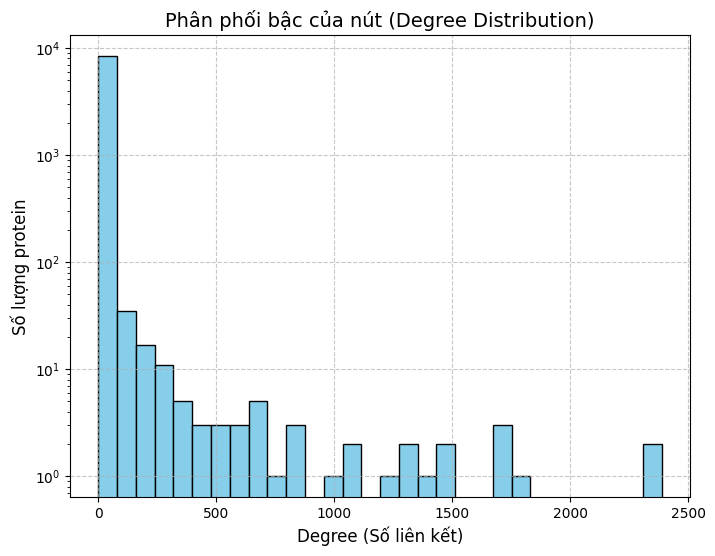

In [23]:
# 2. Chọn cột chứa các tương tác
edges = df[['Official Symbol Interactor A', 'Official Symbol Interactor B']].dropna()
# 3. Tạo đồ thị mạng
G1 = nx.Graph()
G1.add_edges_from(edges.values)

# 4. Tính bậc của mỗi nút
degree_sequence = [d for n, d in G1.degree()]

# 5. Vẽ biểu đồ phân phối bậc (Degree Distribution)
plt.figure(figsize=(8,6))
plt.hist(degree_sequence, bins=30, color='skyblue', edgecolor='black', log=True)
plt.xlabel("Degree (Số liên kết)", fontsize=12)
plt.ylabel("Số lượng protein", fontsize=12)
plt.title("Phân phối bậc của nút (Degree Distribution)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [25]:

# 4. Tính Betweenness Centrality
betweenness = nx.betweenness_centrality(G)

# 5. Tính Closeness Centrality
closeness = nx.closeness_centrality(G)

# 6. Sắp xếp các protein quan trọng nhất
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]

# 7. Hiển thị kết quả
print("Top 10 Protein theo Betweenness Centrality:")
for protein, value in top_betweenness:
    print(f"{protein}: {value:.5f}")

print("\nTop 10 Protein theo Closeness Centrality:")
for protein, value in top_closeness:
    print(f"{protein}: {value:.5f}")

Top 10 Protein theo Betweenness Centrality:
S: 0.16138
M: 0.12611
N: 0.10796
ORF7b: 0.07674
nsp9: 0.06910
TGOLN2: 0.06515
ORF3a: 0.06467
ORF8: 0.06141
E: 0.05384
nsp6: 0.04841

Top 10 Protein theo Closeness Centrality:
M: 0.54114
S: 0.51845
N: 0.51585
ORF7a: 0.50146
ORF3a: 0.50105
E: 0.50007
ORF7b: 0.49806
nsp4: 0.49444
ORF8: 0.49363
ORF6: 0.47948


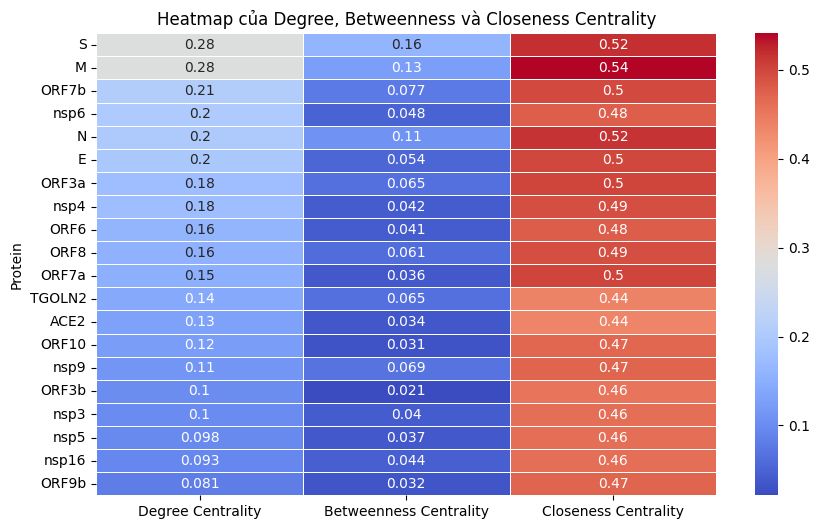

In [26]:
import seaborn as sns
centrality_df = pd.DataFrame({
    "Protein": list(degree_centrality.keys()),
    "Degree Centrality": list(degree_centrality.values()),
    "Betweenness Centrality": list(betweenness.values()),
    "Closeness Centrality": list(closeness.values())
})

# 6. Chọn Top 20 protein có Degree Centrality cao nhất
top_proteins = centrality_df.sort_values(by="Degree Centrality", ascending=False).head(20)

# 7. Vẽ heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(top_proteins.set_index("Protein"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap của Degree, Betweenness và Closeness Centrality")
plt.show()

S và M có Degree Centrality cao nhất (0.28) → Chúng có nhiều kết nối nhất trong mạng, cho thấy vai trò quan trọng trong sự lây lan tín hiệu.

M có Closeness Centrality cao nhất (0.54), theo sau là S (0.52) → Hai protein này có thể truyền tín hiệu nhanh trong mạng.

Betweenness Centrality thấp hơn so với các chỉ số khác → Điều này có thể do mạng có nhiều con đường kết nối khác nhau, giảm sự phụ thuộc vào một số protein làm "cầu nối".

ORF7b, ORF3a, E, nsp6 cũng có mức Closeness Centrality cao → Những protein này có thể có vai trò hỗ trợ quan trọng trong hệ thống.

In [45]:

# Xác định nodes (Protein ID & Symbol)
nodes = pd.concat([df[["BioGRID ID Interactor A", "Official Symbol Interactor A"]],
                   df[["BioGRID ID Interactor B", "Official Symbol Interactor B"]]])
nodes_A = df[["BioGRID ID Interactor A", "Official Symbol Interactor A"]].rename(
    columns={"BioGRID ID Interactor A": "ID", "Official Symbol Interactor A": "Protein"}
)
nodes_B = df[["BioGRID ID Interactor B", "Official Symbol Interactor B"]].rename(
    columns={"BioGRID ID Interactor B": "ID", "Official Symbol Interactor B": "Protein"}
)

# Gộp lại
nodes = pd.concat([nodes_A, nodes_B]).drop_duplicates().reset_index(drop=True)

print(nodes.head())
print("Tổng số node ban đầu (có thông tin ID và protein):", len(nodes))
nodes = nodes.drop_duplicates().reset_index(drop=True)
# Xác định edges (Tương tác giữa protein)
edges = df[["BioGRID ID Interactor A", "BioGRID ID Interactor B"]].drop_duplicates()

# ========================== 2. Xây dựng đồ thị NetworkX ==========================
G = nx.Graph()
G.add_edges_from(edges.values)

       ID Protein
0   31542    MCM5
1   32899    MCM7
2   36697    MCM3
3   34611    RUD3
4  107067   CCND1
Tổng số node ban đầu (có thông tin ID và protein): 8571


In [46]:
# Loại bỏ các cột trùng lặp (chỉ giữ lại một bộ ID - Protein)
nodes = nodes.loc[:, ~nodes.columns.duplicated()]
print(nodes.head())  # Kiểm tra lại dữ liệu sau khi xử lý

       ID Protein
0   31542    MCM5
1   32899    MCM7
2   36697    MCM3
3   34611    RUD3
4  107067   CCND1


In [47]:
nodes["ID"] = nodes["ID"].astype(int)

In [48]:
# Tạo dictionary ánh xạ từ Node ID sang Protein Name
node_info = dict(zip(nodes["ID"], nodes["Protein"]))
nx.set_node_attributes(G, node_info, name="Protein")

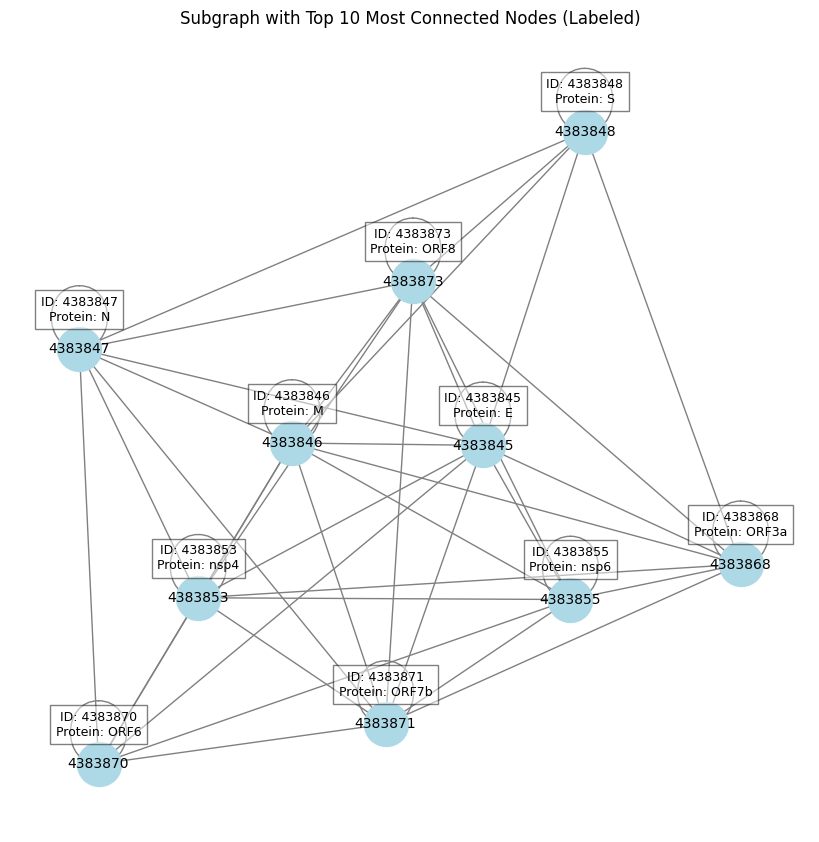

In [49]:
# Chọn 10 node có nhiều liên kết nhất
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
subgraph_nodes = [node for node, _ in top_nodes]
subgraph = G.subgraph(subgraph_nodes)  # Tạo subgraph

# Vẽ đồ thị với layout tối ưu liên kết
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(subgraph, seed=42)  # Giữ node có nhiều liên kết gần nhau
nx.draw(subgraph, pos, with_labels=True, node_size=1000, node_color="lightblue", font_size=10, edge_color="gray")

# Đẩy thuộc tính ra xa khỏi node
offset = 0.08  # Điều chỉnh khoảng cách giữa node và text
for node, (x, y) in pos.items():
    protein_name = node_info.get(node, "Unknown")  # Lấy Protein Name từ dictionary
    text = f"ID: {node}\nProtein: {protein_name}"  # Hiển thị cả ID và Protein Name
    plt.text(x, y + offset, text, fontsize=9, ha='center', bbox=dict(facecolor="white", alpha=0.5))

plt.title("Subgraph with Top 10 Most Connected Nodes (Labeled)")
plt.show()

In [50]:
# Số lượng nodes (đỉnh)
num_nodes = G.number_of_nodes()
print(f"Số lượng nodes: {num_nodes}")

# Số lượng edges (cạnh)
num_edges = G.number_of_edges()
print(f"Số lượng edges: {num_edges}")

Số lượng nodes: 8571
Số lượng edges: 49029


#Trích xuất các đặc trưng

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import networkx as nx
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

 Degree Centrality – Trung tâm theo số kết nối

1. Ý nghĩa: Số lượng liên kết của mỗi protein.
2. Ứng dụng: Protein có degree cao thường là hub, quan trọng trong mạng lưới.


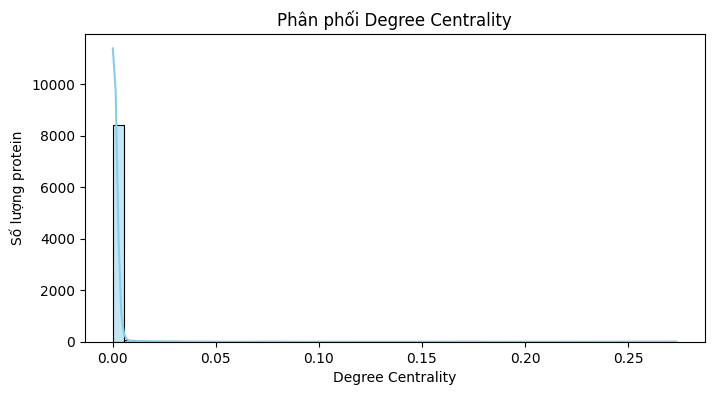

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

deg_centrality = nx.degree_centrality(G)
plt.figure(figsize=(8,4))
sns.histplot(list(deg_centrality.values()), bins=50, kde=True, color='skyblue')
plt.title("Phân phối Degree Centrality")
plt.xlabel("Degree Centrality")
plt.ylabel("Số lượng protein")
plt.show()


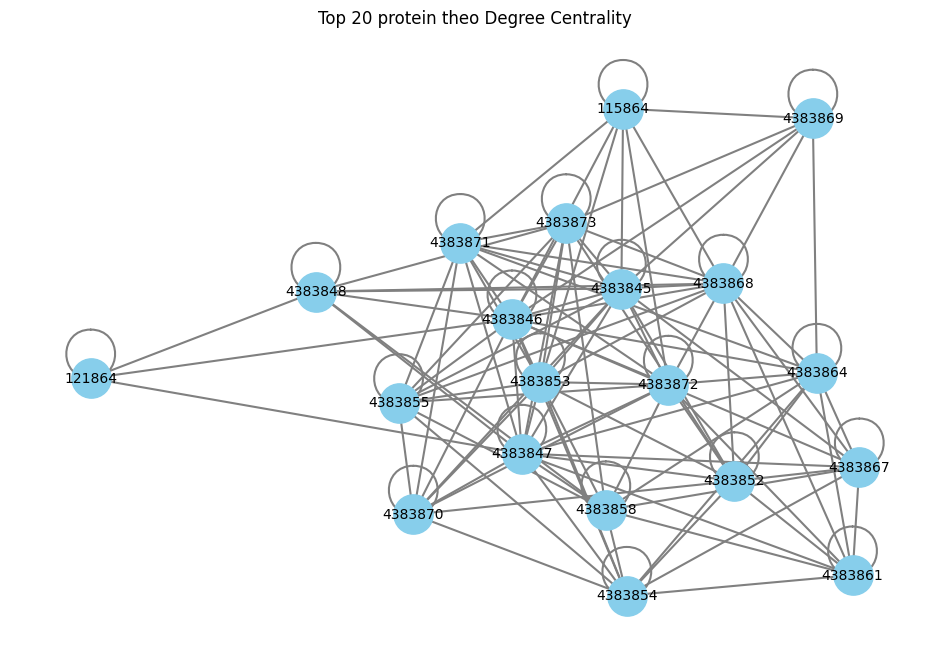

In [60]:
# Sắp xếp theo degree centrality
top_deg_nodes = sorted(deg_centrality, key=deg_centrality.get, reverse=True)[:20]

# Tạo đồ thị con từ 20 protein đó
G_top_deg = G.subgraph(top_deg_nodes)

# Vẽ đồ thị
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_deg, seed=42)  # sơ đồ dạng lò xo
nx.draw_networkx_nodes(G_top_deg, pos, node_size=800, node_color='skyblue')
nx.draw_networkx_edges(G_top_deg, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_deg, pos, font_size=10)
plt.title("Top 20 protein theo Degree Centrality")
plt.axis('off')
plt.show()


Closeness Centrality – Mức độ gần trung tâm


1.   Ý nghĩa: Đo khoảng cách trung bình từ một protein đến tất cả các protein khác trong mạng.
2.   Ứng dụng: Protein có closeness cao thường truyền tín hiệu hoặc tác động nhanh đến các phần còn lại.



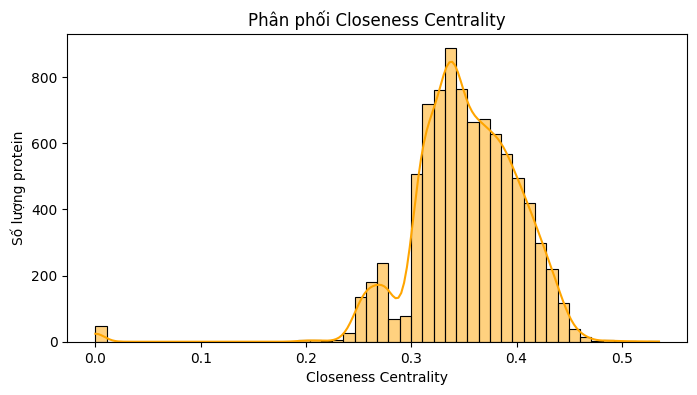

In [53]:
closeness = nx.closeness_centrality(G)
plt.figure(figsize=(8,4))
sns.histplot(list(closeness.values()), bins=50, kde=True, color='orange')
plt.title("Phân phối Closeness Centrality")
plt.xlabel("Closeness Centrality")
plt.ylabel("Số lượng protein")
plt.show()


Betweenness Centrality – Mức độ cầu nối


1.   Ý nghĩa: Số lần một protein nằm trên đường đi ngắn nhất giữa các cặp protein khác.
2.   Ứng dụng: Protein này như “cầu nối” quan trọng – ngắt nó có thể chia mạng.



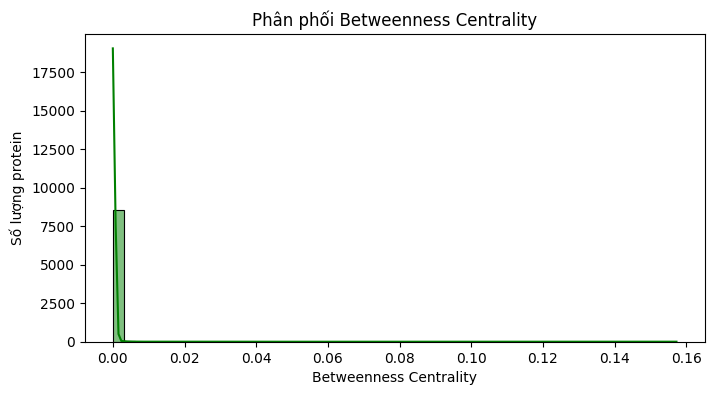

In [54]:
betweenness = nx.betweenness_centrality(G)
plt.figure(figsize=(8,4))
sns.histplot(list(betweenness.values()), bins=50, kde=True, color='green')
plt.title("Phân phối Betweenness Centrality")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Số lượng protein")
plt.show()


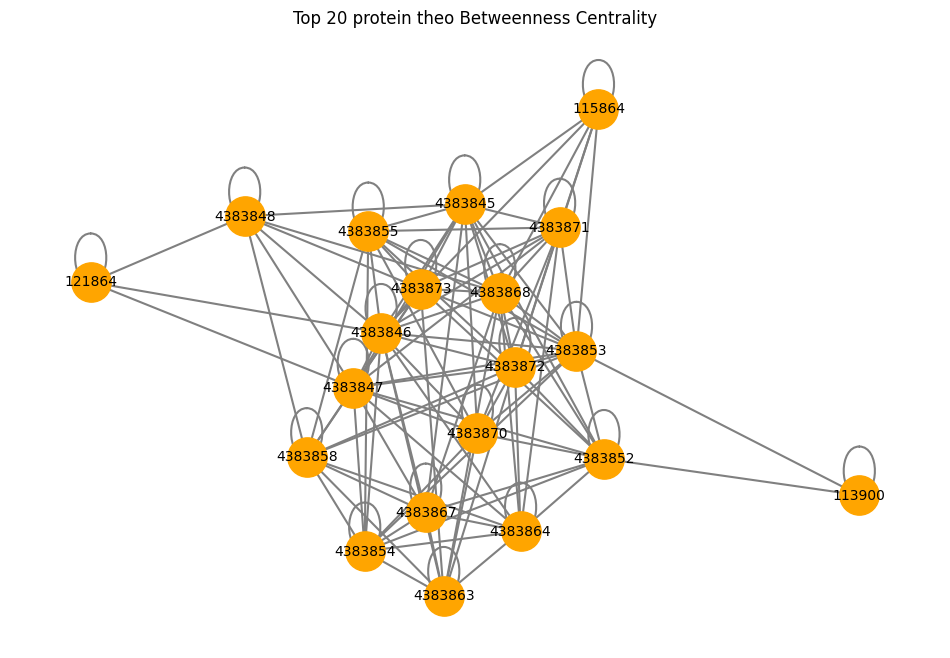

In [58]:
top_bet_nodes = sorted(betweenness, key=betweenness.get, reverse=True)[:20]
G_top_bet = G.subgraph(top_bet_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_bet, seed=42)
nx.draw_networkx_nodes(G_top_bet, pos, node_size=800, node_color='orange')
nx.draw_networkx_edges(G_top_bet, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_bet, pos, font_size=10)
plt.title("Top 20 protein theo Betweenness Centrality")
plt.axis('off')
plt.show()


Eigenvector Centrality – Mức độ ảnh hưởng


1.   Ý nghĩa: Một protein quan trọng nếu nó kết nối với các protein cũng quan trọng.
2.   Ứng dụng: Xác định protein có ảnh hưởng sâu rộng, không chỉ đơn thuần có nhiều kết nối.



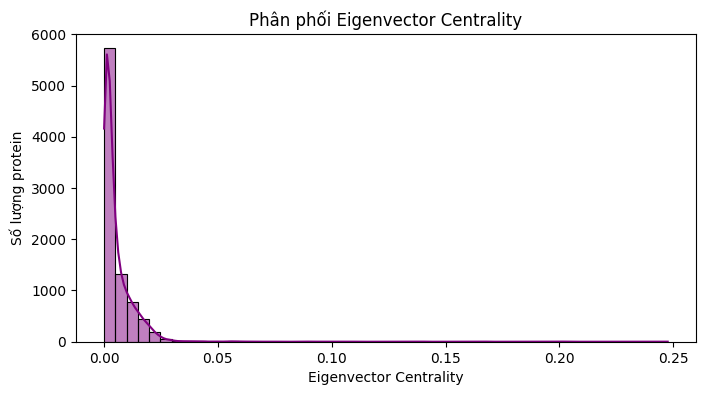

In [55]:
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)
plt.figure(figsize=(8,4))
sns.histplot(list(eigenvector.values()), bins=50, kde=True, color='purple')
plt.title("Phân phối Eigenvector Centrality")
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Số lượng protein")
plt.show()


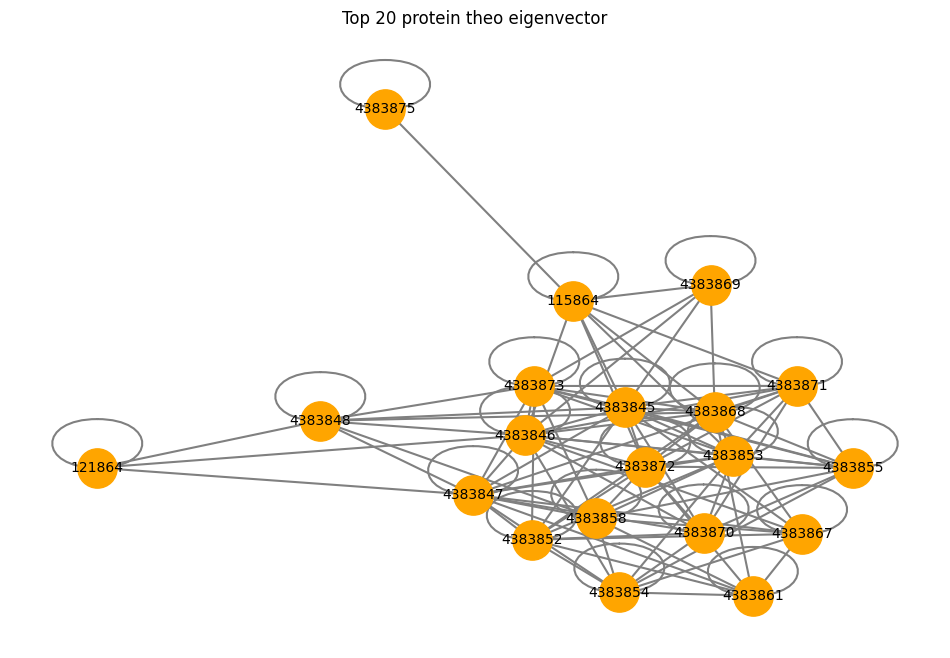

In [59]:
top_bet_nodes = sorted(eigenvector, key=eigenvector.get, reverse=True)[:20]
G_top_bet = G.subgraph(top_bet_nodes)

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_top_bet, seed=42)
nx.draw_networkx_nodes(G_top_bet, pos, node_size=800, node_color='orange')
nx.draw_networkx_edges(G_top_bet, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_top_bet, pos, font_size=10)
plt.title("Top 20 protein theo eigenvector")
plt.axis('off')
plt.show()


Clustering Coefficient – Hệ số kết cụm


1.   Ý nghĩa: Xác suất các protein xung quanh một protein cũng tương tác với nhau.
2.  Ứng dụng: Xác định vùng mạng có tính mô-đun, nơi các protein cùng thực hiện một chức năng sinh học.



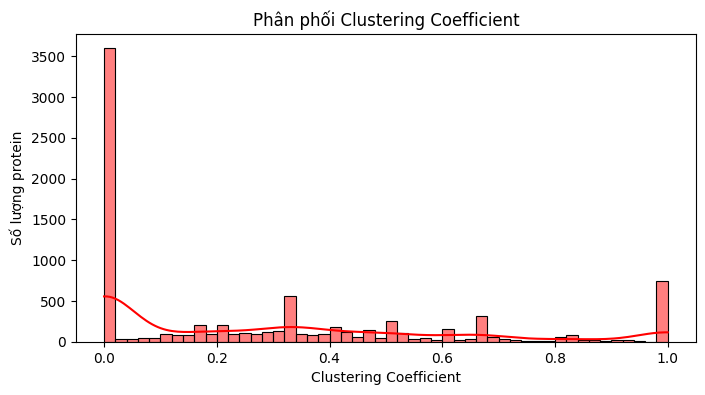

In [56]:
clustering = nx.clustering(G)
plt.figure(figsize=(8,4))
sns.histplot(list(clustering.values()), bins=50, kde=True, color='red')
plt.title("Phân phối Clustering Coefficient")
plt.xlabel("Clustering Coefficient")
plt.ylabel("Số lượng protein")
plt.show()


# Áp dụng GCN

In [66]:
# ====== TẠO NODE FEATURES ======
degree = dict(G.degree())
pagerank = nx.pagerank(G)

degree_tensor = torch.tensor([degree[node] for node in G.nodes()], dtype=torch.float).unsqueeze(1)
clustering_tensor = torch.tensor([clustering[node] for node in G.nodes()], dtype=torch.float).unsqueeze(1)
pagerank_tensor = torch.tensor([pagerank[node] for node in G.nodes()], dtype=torch.float).unsqueeze(1)
betweenness_tensor = torch.tensor([betweenness[node] for node in G.nodes()], dtype=torch.float).unsqueeze(1)

node_idx_mapping = {node: idx for idx, node in enumerate(G.nodes())}

edge_list = [(node_idx_mapping[u], node_idx_mapping[v]) for u, v in G.edges()]
random.shuffle(edge_list)

In [67]:

triangle_count = nx.triangles(G)  # Số tam giác mà node thuộc về

In [68]:
eigenvector_tensor = torch.tensor([eigenvector[node] for node in G.nodes()], dtype=torch.float).unsqueeze(1)
triangle_tensor = torch.tensor([triangle_count[node] for node in G.nodes()], dtype=torch.float).unsqueeze(1)

In [71]:
# Ghép các đặc trưng lại với nhau
x_nx = torch.cat([degree_tensor, clustering_tensor, pagerank_tensor, betweenness_tensor,
                  eigenvector_tensor, triangle_tensor], dim=1)

In [72]:
# Chuẩn hóa đặc trưng
scaler = StandardScaler()
x_np_scaled = scaler.fit_transform(x_nx.numpy())
x_nx = torch.tensor(x_np_scaled, dtype=torch.float)

In [73]:
import random
from torch_geometric.data import Data

# edge_list = list(G.edges())  # hoặc list(G.edges(data=False)) nếu có thuộc tính
edge_list = list(G.edges())
random.shuffle(edge_list)

# Ánh xạ toàn bộ edge_list sang index từ node_idx_mapping
edge_list_idx = [(node_idx_mapping[u], node_idx_mapping[v]) for u, v in G.edges()]

# Chia train/test từ danh sách đã được ánh xạ
num_edges = len(edge_list_idx)
train_edges = edge_list_idx[:int(0.8 * num_edges)]
test_edges = edge_list_idx[int(0.8 * num_edges):]

# Tạo edge_index
edge_index_train = torch.tensor(train_edges, dtype=torch.long).t().contiguous()
edge_index_test = torch.tensor(test_edges, dtype=torch.long).t().contiguous()
edge_index_all = torch.tensor(edge_list_idx, dtype=torch.long).t().contiguous()

In [74]:
node_idx_mapping = {node: idx for idx, node in enumerate(G.nodes())}
# Map lại edge_list theo chỉ số
edge_index_mapped = torch.tensor([
    [node_idx_mapping[u], node_idx_mapping[v]] for u, v in edge_list
], dtype=torch.long).t().contiguous()

data = Data(x=x_nx, edge_index=edge_index_mapped)

In [75]:
class GCNEncoder(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super(GCNEncoder, self).__init__()
        self.conv1 = GCNConv(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64)

        self.conv2 = GCNConv(64, 128)
        self.bn2 = nn.BatchNorm1d(128)

        self.conv3 = GCNConv(128, 64)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.leaky_relu(x, 0.2)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.leaky_relu(x, 0.2)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        return x

In [76]:
def hadamard(u, v):
    return u * v

In [77]:
class EdgeDecoder(nn.Module):
    def __init__(self, input_dim):
        super(EdgeDecoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, edge_features):
        x = F.relu(self.fc1(edge_features))
        x = torch.sigmoid(self.fc2(x))  # nếu dùng BCE Loss
        return x

In [78]:
model = GCNEncoder(input_dim=x_nx.shape[1]).to(device)
decoder = EdgeDecoder(input_dim=64).to(device)  # đầu vào của decoder là kích thước vector hadamard (64)

optimizer = optim.Adam(
    list(model.parameters()) + list(decoder.parameters()),
    lr=0.001, weight_decay=5e-4
)

In [79]:
# ====== TRAIN FUNCTION ======
def train():
    model.train()
    decoder.train()
    optimizer.zero_grad()

    emb = model(data.x, data.edge_index)
    emb = F.normalize(emb, p=2, dim=1)

    # Positive samples
    src_pos, dst_pos = edge_index_train
    pos_edge_feat = hadamard(emb[src_pos], emb[dst_pos])
    pos_preds = decoder(pos_edge_feat).squeeze()

    # Negative samples
    neg_edge_index = negative_sampling(
        edge_index=data.edge_index,
        num_nodes=data.num_nodes,
        num_neg_samples=len(src_pos),
        force_undirected=True
    ).to(device)

    neg_src, neg_dst = neg_edge_index
    neg_edge_feat = hadamard(emb[neg_src], emb[neg_dst])
    neg_preds = decoder(neg_edge_feat).squeeze()

    # Labels
    preds = torch.cat([pos_preds, neg_preds])
    labels = torch.cat([
        torch.ones_like(pos_preds),
        torch.zeros_like(neg_preds)
    ])

    loss = F.binary_cross_entropy(preds, labels)
    loss.backward()
    optimizer.step()
    return loss.item()


# ====== EVALUATION FUNCTION ======
def evaluate():
    model.eval()
    decoder.eval()
    with torch.no_grad():
        emb = model(data.x, data.edge_index)
        emb = F.normalize(emb, p=2, dim=1)

        src_pos, dst_pos = edge_index_test
        pos_edge_feat = hadamard(emb[src_pos], emb[dst_pos])
        pos_preds = decoder(pos_edge_feat).squeeze()

        neg_edge_index = negative_sampling(
            edge_index=data.edge_index,
            num_nodes=data.num_nodes,
            num_neg_samples=len(src_pos),
            force_undirected=True
        ).to(device)

        neg_src, neg_dst = neg_edge_index
        neg_edge_feat = hadamard(emb[neg_src], emb[neg_dst])
        neg_preds = decoder(neg_edge_feat).squeeze()

        preds = torch.cat([pos_preds, neg_preds]).cpu().numpy()
        labels = torch.cat([
            torch.ones_like(pos_preds),
            torch.zeros_like(neg_preds)
        ]).cpu().numpy()

        auc = roc_auc_score(labels, preds)
        return auc

In [80]:
num_epochs = 50
loss_values = []
auc_values = []
precision_values = []
recall_values = []
f1_values = []
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)
for epoch in range(1, num_epochs + 1):
    loss = train()
    auc = evaluate()

    # Lưu các giá trị vào danh sách
    loss_values.append(loss)
    auc_values.append(auc)

    print(f"Epoch {epoch}/{num_epochs}, Loss: {loss:.4f}, AUC: {auc:.4f}")
    scheduler.step()

Epoch 1/50, Loss: 0.6981, AUC: 0.6232
Epoch 2/50, Loss: 0.6978, AUC: 0.7052
Epoch 3/50, Loss: 0.6972, AUC: 0.7022
Epoch 4/50, Loss: 0.6971, AUC: 0.7132
Epoch 5/50, Loss: 0.6962, AUC: 0.7861
Epoch 6/50, Loss: 0.6961, AUC: 0.8433
Epoch 7/50, Loss: 0.6955, AUC: 0.8831
Epoch 8/50, Loss: 0.6954, AUC: 0.8908
Epoch 9/50, Loss: 0.6949, AUC: 0.8968
Epoch 10/50, Loss: 0.6947, AUC: 0.8995
Epoch 11/50, Loss: 0.6941, AUC: 0.8962
Epoch 12/50, Loss: 0.6942, AUC: 0.8953
Epoch 13/50, Loss: 0.6938, AUC: 0.8933
Epoch 14/50, Loss: 0.6938, AUC: 0.8890
Epoch 15/50, Loss: 0.6932, AUC: 0.8820
Epoch 16/50, Loss: 0.6933, AUC: 0.8826
Epoch 17/50, Loss: 0.6928, AUC: 0.8813
Epoch 18/50, Loss: 0.6924, AUC: 0.8741
Epoch 19/50, Loss: 0.6926, AUC: 0.8775
Epoch 20/50, Loss: 0.6930, AUC: 0.8765
Epoch 21/50, Loss: 0.6920, AUC: 0.8840
Epoch 22/50, Loss: 0.6924, AUC: 0.8897
Epoch 23/50, Loss: 0.6915, AUC: 0.8924
Epoch 24/50, Loss: 0.6914, AUC: 0.8882
Epoch 25/50, Loss: 0.6910, AUC: 0.8866
Epoch 26/50, Loss: 0.6908, AUC: 0.

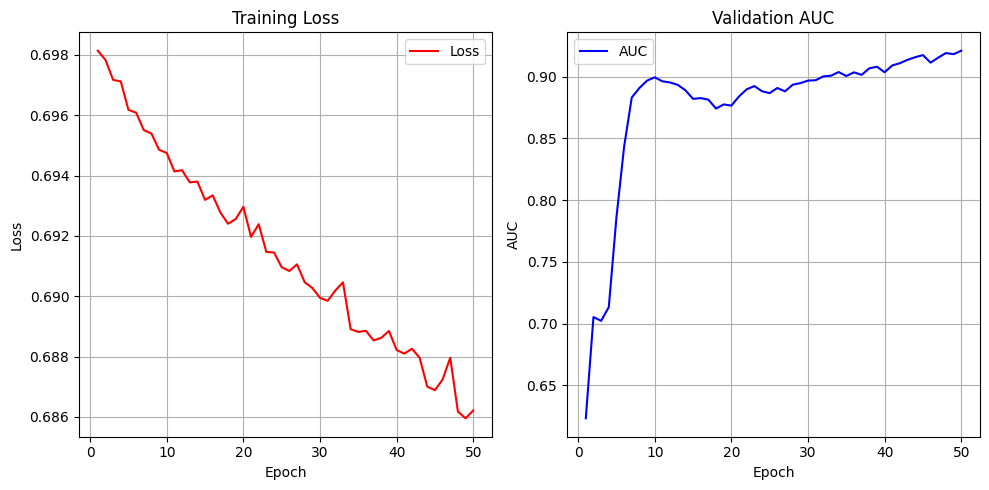

In [81]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))

# Vẽ biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'r-', label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

# Vẽ biểu đồ AUC
plt.subplot(1, 2, 2)
plt.plot(epochs, auc_values, 'b-', label='AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation AUC')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [82]:
def get_unconnected_pairs(G, num_samples=10):
    nodes = list(G.nodes())
    unconnected = []
    attempts = 0
    while len(unconnected) < num_samples and attempts < num_samples * 10:
        u, v = random.sample(nodes, 2)
        if not G.has_edge(u, v) and (u, v) not in unconnected and (v, u) not in unconnected:
            unconnected.append((u, v))
        attempts += 1
    return unconnected

In [83]:
def predict_unseen_links(pairs, model, data, node_idx_mapping, node_info):
    model.eval()
    with torch.no_grad():
        emb = model(data.x, data.edge_index)
        emb = F.normalize(emb, p=2, dim=1)

        results = []
        for u, v in pairs:
            idx_u, idx_v = node_idx_mapping[u], node_idx_mapping[v]
            score = (emb[idx_u] * emb[idx_v]).sum().item()
            results.append({
                "Protein A ID": u,
                "Protein A": node_info[u],
                "Protein B ID": v,
                "Protein B": node_info[v],
                "Score": score
            })

        # Sắp xếp theo điểm từ cao xuống
        results.sort(key=lambda x: x["Score"], reverse=True)
        return results

In [84]:
# Lấy 10 cặp node chưa kết nối
unseen_pairs = get_unconnected_pairs(G, num_samples=10)

# Dự đoán điểm liên kết
predictions = predict_unseen_links(unseen_pairs, model, data, node_idx_mapping, node_info)

# In kết quả
for i, pred in enumerate(predictions, 1):
    print(f"{i:2d}. {pred['Protein A']} ({pred['Protein A ID']}) ↔ {pred['Protein B']} ({pred['Protein B ID']}) | Score: {pred['Score']:.4f}")

 1. PPIH (115728) ↔ MRPL12 (112097) | Score: 0.8916
 2. ARFGAP1 (120856) ↔ OSGEP (120779) | Score: 0.8644
 3. ALG8 (122511) ↔ UGCG (113204) | Score: 0.7911
 4. SLC51B (125821) ↔ TBRG4 (114666) | Score: 0.7204
 5. MRPL57 (122459) ↔ HBA1 (109289) | Score: 0.7047
 6. PPIL4 (124467) ↔ PPFIBP2 (114067) | Score: 0.6127
 7. ATP6V1D (119513) ↔ CDKL3 (119419) | Score: 0.5746
 8. PPHLN1 (119596) ↔ LANCL2 (120998) | Score: 0.5538
 9. COL16A1 (107703) ↔ LBX1 (115903) | Score: 0.4497
10. PFN2 (111238) ↔ WWTR1 (117434) | Score: -0.2393
